Mounted at /content/drive
Current directory: /content/drive/MyDrive/MBP_PREDICTOR
Dataset loaded: (3200, 3)
Columns: ['Protein_ID', 'Sequence', 'Label']

Class distribution:
Positive (MBP): 1600
Negative (Non-MBP): 1600

SEQUENCE LENGTH ANALYSIS

Length Statistics:
Mean: 740.4
Median: 570.5
Min: 16
Max: 7570
Std: 664.7

Length Percentiles:
 1%:   85 AA
 5%:  145 AA
10%:  223 AA
25%:  354 AA
50%:  570 AA
75%:  890 AA
90%: 1397 AA
95%: 1903 AA
99%: 3364 AA

Length Categories:
Very short (<30 AA): 2 (0.1%)
Medium long (>1000 AA): 635 (19.8%)
Very long (>2500 AA): 70 (2.2%)


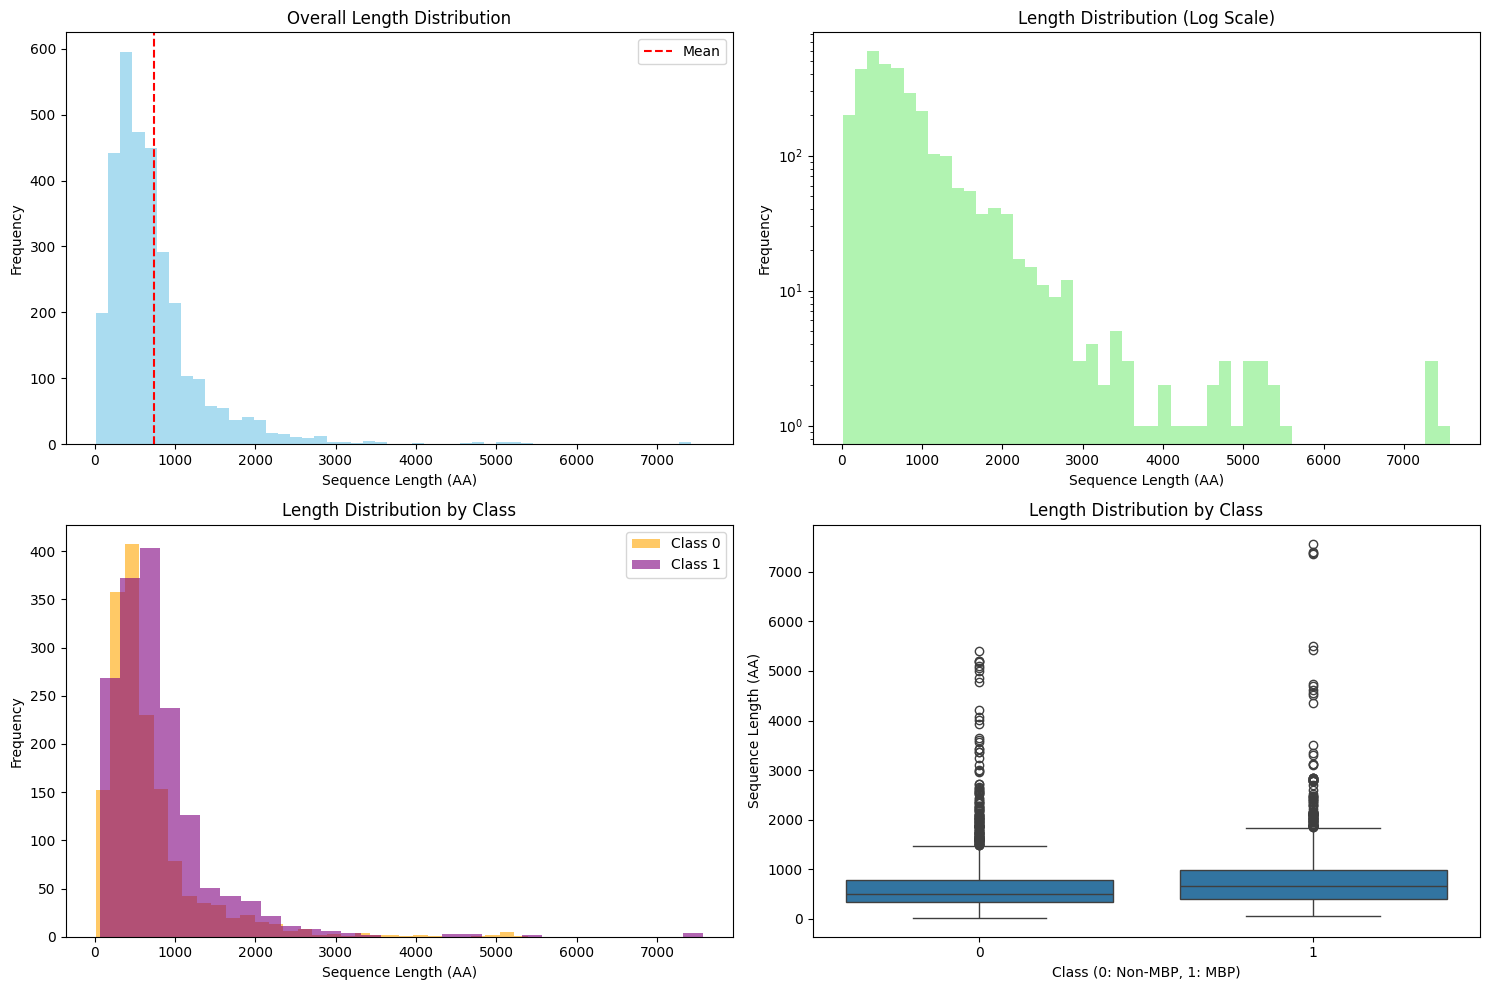


AMINO ACID COMPOSITION ANALYSIS
Standard amino acids found: ['A', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'P', 'Q', 'R', 'S', 'T', 'V', 'W', 'Y']
Invalid characters found: ['U', 'X']
  'U': 1 occurrences in 1 sequences
  'X': 26 occurrences in 9 sequences

Sequences with >10% unknown AAs: 0 (0.0%)

DUPLICATE ANALYSIS
Exact duplicate sequences: 76 (2.4%)

Duplicate sequence groups:
Sequence length 245 AA appears 2 times:
  Q9ERW3 (Label: 1)
  P70377 (Label: 1)

Sequence length 245 AA appears 2 times:
  Q5RDS9 (Label: 1)
  Q92913 (Label: 1)

Sequence length 253 AA appears 2 times:
  P67992 (Label: 1)
  P67997 (Label: 1)

Sequence length 85 AA appears 2 times:
  B1NWS4 (Label: 0)
  B1NWR6 (Label: 0)

Sequence length 281 AA appears 2 times:
  Q6PER3 (Label: 1)
  Q5XIT1 (Label: 1)

Sequence length 243 AA appears 2 times:
  P62908 (Label: 1)
  P62909 (Label: 1)

Sequence length 345 AA appears 2 times:
  Q78PB6 (Label: 1)
  Q9ERR1 (Label: 1)

Sequence length 66 AA appears 2 ti

In [1]:
from google.colab import drive
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re

# Mount Google Drive
drive.mount('/content/drive')

import os
os.chdir('/content/drive/MyDrive/MBP_PREDICTOR')
print(f"Current directory: {os.getcwd()}")

# Load dataset
df = pd.read_csv('data/mbp_dataset.csv')
print(f"Dataset loaded: {df.shape}")
print(f"Columns: {list(df.columns)}")

# Fix column names if needed
if 'protein_id' in df.columns:
    df = df.rename(columns={'protein_id': 'Protein_ID', 'sequence': 'Sequence', 'target': 'Label'})
    print("Fixed column names")

print(f"\nClass distribution:")
print(f"Positive (MBP): {sum(df['Label'] == 1)}")
print(f"Negative (Non-MBP): {sum(df['Label'] == 0)}")

# ============================================================================
# SEQUENCE LENGTH ANALYSIS
# ============================================================================

print("\n" + "="*60)
print("SEQUENCE LENGTH ANALYSIS")
print("="*60)

df['Seq_Length'] = df['Sequence'].str.len()

# Basic statistics
print(f"\nLength Statistics:")
print(f"Mean: {df['Seq_Length'].mean():.1f}")
print(f"Median: {df['Seq_Length'].median():.1f}")
print(f"Min: {df['Seq_Length'].min()}")
print(f"Max: {df['Seq_Length'].max()}")
print(f"Std: {df['Seq_Length'].std():.1f}")

# Length distribution by percentiles
percentiles = [1, 5, 10, 25, 50, 75, 90, 95, 99]
print(f"\nLength Percentiles:")
for p in percentiles:
    val = np.percentile(df['Seq_Length'], p)
    print(f"{p:2d}%: {val:4.0f} AA")

# Extreme length analysis
very_short = df['Seq_Length'] < 30
very_long = df['Seq_Length'] > 2500
medium_long = df['Seq_Length'] > 1000

print(f"\nLength Categories:")
print(f"Very short (<30 AA): {sum(very_short)} ({sum(very_short)/len(df)*100:.1f}%)")
print(f"Medium long (>1000 AA): {sum(medium_long)} ({sum(medium_long)/len(df)*100:.1f}%)")
print(f"Very long (>2500 AA): {sum(very_long)} ({sum(very_long)/len(df)*100:.1f}%)")

# Plot length distributions
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Overall distribution
axes[0,0].hist(df['Seq_Length'], bins=50, alpha=0.7, color='skyblue')
axes[0,0].set_xlabel('Sequence Length (AA)')
axes[0,0].set_ylabel('Frequency')
axes[0,0].set_title('Overall Length Distribution')
axes[0,0].axvline(df['Seq_Length'].mean(), color='red', linestyle='--', label='Mean')
axes[0,0].legend()

# Log scale
axes[0,1].hist(df['Seq_Length'], bins=50, alpha=0.7, color='lightgreen')
axes[0,1].set_xlabel('Sequence Length (AA)')
axes[0,1].set_ylabel('Frequency')
axes[0,1].set_title('Length Distribution (Log Scale)')
axes[0,1].set_yscale('log')

# By class
for label, color in [(0, 'orange'), (1, 'purple')]:
    subset = df[df['Label'] == label]['Seq_Length']
    axes[1,0].hist(subset, bins=30, alpha=0.6, label=f'Class {label}', color=color)
axes[1,0].set_xlabel('Sequence Length (AA)')
axes[1,0].set_ylabel('Frequency')
axes[1,0].set_title('Length Distribution by Class')
axes[1,0].legend()

# Boxplot by class
sns.boxplot(data=df, x='Label', y='Seq_Length', ax=axes[1,1])
axes[1,1].set_xlabel('Class (0: Non-MBP, 1: MBP)')
axes[1,1].set_ylabel('Sequence Length (AA)')
axes[1,1].set_title('Length Distribution by Class')

plt.tight_layout()
plt.show()

# ============================================================================
# AMINO ACID COMPOSITION ANALYSIS
# ============================================================================

print("\n" + "="*60)
print("AMINO ACID COMPOSITION ANALYSIS")
print("="*60)

# Check for invalid characters
standard_aa = set('ACDEFGHIKLMNPQRSTVWY')
all_sequences = ''.join(df['Sequence'])
all_chars = set(all_sequences)
invalid_chars = all_chars - standard_aa

print(f"Standard amino acids found: {sorted(all_chars & standard_aa)}")
if invalid_chars:
    print(f"Invalid characters found: {sorted(invalid_chars)}")

    # Count occurrences of each invalid character
    for char in sorted(invalid_chars):
        count = all_sequences.count(char)
        sequences_with_char = sum(1 for seq in df['Sequence'] if char in seq)
        print(f"  '{char}': {count} occurrences in {sequences_with_char} sequences")
else:
    print("All characters are valid amino acids")

# Check for sequences with high unknown content
def count_unknown_aa(sequence):
    unknown = set(sequence) & {'X', 'B', 'Z', 'U', 'O'}
    return sum(sequence.count(char) for char in unknown)

df['Unknown_AA_Count'] = df['Sequence'].apply(count_unknown_aa)
df['Unknown_AA_Percent'] = (df['Unknown_AA_Count'] / df['Seq_Length']) * 100

high_unknown = df['Unknown_AA_Percent'] > 10
print(f"\nSequences with >10% unknown AAs: {sum(high_unknown)} ({sum(high_unknown)/len(df)*100:.1f}%)")

if sum(high_unknown) > 0:
    print("Top sequences with highest unknown AA content:")
    top_unknown = df.nlargest(5, 'Unknown_AA_Percent')[['Protein_ID', 'Seq_Length', 'Unknown_AA_Percent']]
    print(top_unknown)

# ============================================================================
# DUPLICATE ANALYSIS
# ============================================================================

print("\n" + "="*60)
print("DUPLICATE ANALYSIS")
print("="*60)

# Check for exact sequence duplicates
duplicated_sequences = df.duplicated('Sequence', keep=False)
num_duplicates = sum(duplicated_sequences)

print(f"Exact duplicate sequences: {num_duplicates} ({num_duplicates/len(df)*100:.1f}%)")

if num_duplicates > 0:
    # Show duplicate groups
    duplicate_df = df[duplicated_sequences].sort_values('Sequence')
    print(f"\nDuplicate sequence groups:")

    for seq, group in duplicate_df.groupby('Sequence'):
        if len(group) > 1:
            print(f"Sequence length {len(seq)} AA appears {len(group)} times:")
            for _, row in group.iterrows():
                print(f"  {row['Protein_ID']} (Label: {row['Label']})")
            print()

# Check for near-duplicates (high sequence similarity)
print("\nChecking for highly similar sequences (>95% identity)...")

def sequence_similarity(seq1, seq2):
    if len(seq1) != len(seq2):
        return 0.0
    matches = sum(a == b for a, b in zip(seq1, seq2))
    return matches / len(seq1)

# Sample check (only check first 100 sequences to avoid long runtime)
sample_df = df.head(100)
similar_pairs = []

for i in range(len(sample_df)):
    for j in range(i+1, len(sample_df)):
        seq1 = sample_df.iloc[i]['Sequence']
        seq2 = sample_df.iloc[j]['Sequence']
        if len(seq1) == len(seq2):  # Only compare same length sequences
            similarity = sequence_similarity(seq1, seq2)
            if similarity > 0.95:
                similar_pairs.append((i, j, similarity))

if similar_pairs:
    print(f"Found {len(similar_pairs)} highly similar pairs in sample:")
    for i, j, sim in similar_pairs[:5]:  # Show first 5
        print(f"  Sequences {i} and {j}: {sim:.3f} similarity")
else:
    print("No highly similar sequences found in sample")

# ============================================================================
# REPETITIVE SEQUENCE ANALYSIS
# ============================================================================

print("\n" + "="*60)
print("REPETITIVE SEQUENCE ANALYSIS")
print("="*60)

def find_repetitive_sequences(sequence, min_repeat_len=3, min_repeats=5):
    """Find sequences with long repetitive regions"""
    for repeat_len in range(min_repeat_len, min(20, len(sequence)//min_repeats)):
        for i in range(len(sequence) - repeat_len * min_repeats):
            pattern = sequence[i:i+repeat_len]
            count = 1
            pos = i + repeat_len

            while pos <= len(sequence) - repeat_len and sequence[pos:pos+repeat_len] == pattern:
                count += 1
                pos += repeat_len

            if count >= min_repeats:
                return True, pattern, count
    return False, None, 0

repetitive_sequences = []
for idx, row in df.iterrows():
    is_rep, pattern, count = find_repetitive_sequences(row['Sequence'])
    if is_rep:
        repetitive_sequences.append({
            'Protein_ID': row['Protein_ID'],
            'Length': len(row['Sequence']),
            'Pattern': pattern,
            'Repeats': count,
            'Label': row['Label']
        })

print(f"Sequences with repetitive regions: {len(repetitive_sequences)}")

if repetitive_sequences:
    rep_df = pd.DataFrame(repetitive_sequences)
    print("\nTop repetitive sequences:")
    print(rep_df.head(10))

# ============================================================================
# SUMMARY AND CLEANING RECOMMENDATIONS
# ============================================================================

print("\n" + "="*60)
print("SUMMARY AND CLEANING RECOMMENDATIONS")
print("="*60)

print(f"\nDataset Overview:")
print(f"Total sequences: {len(df)}")
print(f"Class balance: {sum(df['Label']==1)} positive, {sum(df['Label']==0)} negative")

print(f"\nIssues Found:")

# Length issues
very_short_count = sum(df['Seq_Length'] < 30)
very_long_count = sum(df['Seq_Length'] > 2500)
print(f"Very short sequences (<30 AA): {very_short_count}")
print(f"Very long sequences (>2500 AA): {very_long_count}")

# Character issues
if invalid_chars:
    print(f"Invalid characters: {len(invalid_chars)} types")

high_unknown_count = sum(df['Unknown_AA_Percent'] > 10)
print(f"High unknown AA content (>10%): {high_unknown_count}")

# Duplicate issues
print(f"Exact duplicates: {num_duplicates}")
print(f"Repetitive sequences: {len(repetitive_sequences)}")

print(f"\nCleaning Recommendations:")
print("1. CRITICAL - Remove very short sequences (<30 AA)")
print("2. CRITICAL - Remove very long sequences (>2500 AA)")
print("3. HIGH - Remove/fix sequences with invalid characters")
print("4. HIGH - Remove exact duplicates")
print("5. MEDIUM - Remove sequences with >15% unknown AAs")
print("6. LOW - Consider removing highly repetitive sequences")

# Calculate potential data loss
total_to_remove = very_short_count + very_long_count + num_duplicates + high_unknown_count
remaining = len(df) - total_to_remove
print(f"\nEstimated sequences remaining after cleaning: {remaining}")
print(f"Data retention: {remaining/len(df)*100:.1f}%")

# ============================================================================
# APPLY CLEANING FILTERS
# ============================================================================

print("\n" + "="*60)
print("APPLYING CLEANING FILTERS")
print("="*60)

# Create cleaning masks
mask_length = (df['Seq_Length'] >= 30) & (df['Seq_Length'] <= 2500)
mask_no_invalid = ~df['Sequence'].str.contains('|'.join(invalid_chars)) if invalid_chars else pd.Series([True]*len(df))
mask_low_unknown = df['Unknown_AA_Percent'] <= 15
mask_no_duplicates = ~df.duplicated('Sequence', keep='first')

print("Cleaning steps:")
print(f"Original dataset: {len(df)} sequences")

# Apply filters step by step
df_cleaned = df.copy()

# Step 1: Length filter
df_cleaned = df_cleaned[mask_length]
print(f"After length filter (30-2500 AA): {len(df_cleaned)} sequences")

# Step 2: Invalid character filter
if invalid_chars:
    df_cleaned = df_cleaned[mask_no_invalid.loc[df_cleaned.index]]
    print(f"After removing invalid characters: {len(df_cleaned)} sequences")

# Step 3: Unknown AA filter
df_cleaned = df_cleaned[mask_low_unknown.loc[df_cleaned.index]]
print(f"After removing high unknown AA content: {len(df_cleaned)} sequences")

# Step 4: Duplicate filter
df_cleaned = df_cleaned[mask_no_duplicates.loc[df_cleaned.index]]
print(f"After removing duplicates: {len(df_cleaned)} sequences")

# Check final class balance
final_pos = sum(df_cleaned['Label'] == 1)
final_neg = sum(df_cleaned['Label'] == 0)
print(f"\nFinal class distribution:")
print(f"Positive: {final_pos}")
print(f"Negative: {final_neg}")
print(f"Balance ratio: {final_pos/final_neg:.3f}")

# Save cleaned dataset
df_cleaned_final = df_cleaned[['Protein_ID', 'Sequence', 'Label']].copy()
df_cleaned_final.to_csv('data/mbp_dataset_cleaned.csv', index=False)
print(f"\nCleaned dataset saved to: data/mbp_dataset_cleaned.csv")
print(f"Ready for feature extraction!")